# Medical Data Visualizer

### Data description:
The rows in the dataset represent patients and the columns represent information like body measurements, results from various blood tests, and lifestyle choices. You will use the dataset to explore the relationship between cardiac disease, body measurements, blood markers, and lifestyle choices.

| Feature Variable | Variable Type | Variable | Value Type |
|---|---|---|---|
| Age | Objective Feature | `age` | int (days) |
| Height | Objective Feature | `height` | int (cm) |
| Weight | Objective Feature | `weight` | float (kg) |
| Gender | Objective Feature | `gender` | categorical code |
| Systolic blood pressure | Examination Feature | `ap_hi` | int |
| Diastolic blood pressure | Examination Feature | `ap_lo` | int |
| Cholesterol | Examination Feature | `cholesterol` | 1: normal, 2: above normal, 3: well above normal |
| Glucose | Examination Feature | `gluc` | 1: normal, 2: above normal, 3: well above normal |
| Smoking | Subjective Feature | `smoke` | binary |
| Alcohol intake | Subjective Feature | `alco` | binary |
| Physical activity | Subjective Feature | `active` | binary |
| Presence or absence of cardiovascular disease | Target Variable | `cardio` | binary |

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
# Import the data from medical_examination.csv and assign it to the df variable.
df = pd.read_csv("medical_examination.csv")
df.head(3)

,id,age,sex,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1


In [9]:
# Add an overweight column to the data. To determine if a person is overweight, 
# first calculate their BMI by dividing their weight in kilograms by the square of their height in meters. 
# If that value is > 25 then the person is overweight. Use the value 0 for NOT overweight and the value 1 for overweight.
df["height"] = df["height"] / 100
BMI = df["weight"] / df["height"]**2
df["overweight"] = np.where(BMI < 25, 0, 1)
# or
# df = df.assign(overweight= lambda x: x["weight"] / np.power(x["height"], 2) > 25).astype(int)

In [10]:
# Normalize data by making 0 always good and 1 always bad. 
# If the value of cholesterol or gluc is 1, set the value to 0. 
# If the value is more than 1, set the value to 1.
df["cholesterol"] = np.where(df["cholesterol"]==1, 0, 1)
df["gluc"] = np.where(df["gluc"]==1, 0, 1)

### pd.melt():
pandas.melt() is a function in **pandas** used to reshape a DataFrame from **wide format** to **long format** by converting multiple columns into rows.
```
df = pd.DataFrame({
    "name": ["Ali", "Sara"],
    "math": [90, 85],
    "english": [88, 92]
})
pd.melt(df, id_vars=["name"])
```
Result:<br/>
| name | variable | value |
| ---- | -------- | ----- |
| Ali  | math     | 90    |
| Sara | math     | 85    |
| Ali  | english  | 88    |
| Sara | english  | 92    |

Key idea:
- **value_vars** is a list of columns that you want to transform into the value column in the melted DataFrame.

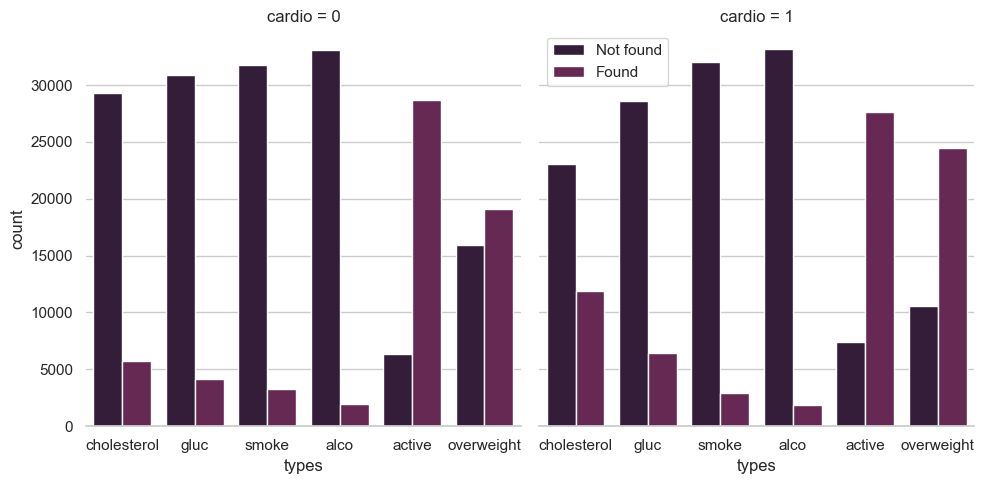

In [13]:
# Draw the Categorical Plot in the draw_cat_plot function.
# Create a DataFrame for the cat plot using pd.melt with values from cholesterol, gluc, smoke, alco, active, and overweight in the df_cat variable.
# Group and reformat the data in df_cat to split it by cardio.
def draw_cat_plot(data):
    df_cat = pd.melt(data,id_vars="cardio",var_name="types",
                     value_vars=["cholesterol", "gluc", "smoke", "alco", "active", "overweight"])
    
# Create a chart that shows the value counts of the categorical features using the method provided by the seaborn library import: sns.catplot().
# Get the figure for the output and store it in the fig variable.
    sns.set_theme(style="whitegrid", palette="rocket")
    fig = sns.catplot(data=df_cat, x="types",hue="value", kind="count", col="cardio", legend=False)
    fig.despine(left=True)
    plt.legend(labels=["Not found","Found"], loc="upper left")
    return fig
    
draw_cat_plot(df)

> The graph shows that overweight, high cholesterol and high glucose are the strongest factors associated with cardiovascular disease in this dataset.